In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random as rd

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        
        #P.N i can directlhy assign two values from a tuple to two corresponding variables like so: row,column=(x,y)
       
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions=[]
        row,col=state
        for action in MOVES:
            rm,cm=MOVES[action]
            n_cell=(row+rm,col+cm)
            if self.in_bounds(n_cell) and self.is_free(n_cell):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row,col=state
        rm,cm=MOVES[action]
        return(row + rm, col + cm)
       
    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
      

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

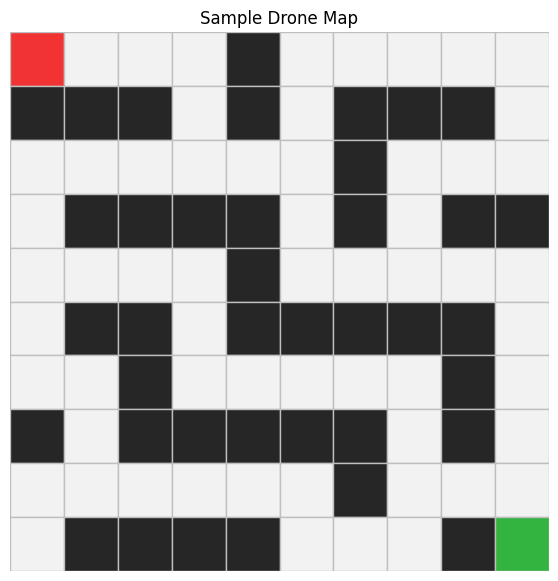

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        ## IMPLEMENTATION
        current_state=node.state
        for action in problem.actions(current_state):
            child=problem.result(current_state, action)
            cost=node.path_cost + problem.action_cost(current_state,action,child)
            yield Node(state=child, parent=node, action=action, path_cost=cost)
        

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        # TODO 6:
        node=Node(
            state=problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0
        )
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm ="BFS",
                status= "success",
                solution= node,
                nodes_expanded= 0,
                max_frontier_size=0,
                reached_count = 0
                )
        frontier=deque([node])
        max_frontier_size=len(frontier)
        reached={problem.initial_state()}
        nodes_expanded=0
        while frontier:
            node=frontier.popleft()
            nodes_expanded+=1
            for child in self.expand(problem,node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm ="BFS",
                        status= "success",
                        solution= child,
                        nodes_expanded= nodes_expanded,
                        max_frontier_size=max(max_frontier_size, len(frontier)),
                        reached_count = len(reached)
                    )
                if not(child.state in reached):
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size=max(max_frontier_size, len(frontier))
            
        return SearchResult(
                        algorithm ="BFS",
                        status= "failure",
                        solution= None,
                        nodes_expanded= nodes_expanded,
                        max_frontier_size=max(max_frontier_size, len(frontier)),
                        reached_count = len(reached),
                    )
            

In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        node = Node(
            state=problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0
        )
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm ="DFS",
                status= "success",
                solution= node,
                nodes_expanded= 0,
                max_frontier_size=0,
                reached_count = 0
                )
        frontier=[node]
        reached={problem.initial_state()}
        nodes_expanded=0
        max_frontier_size=len(frontier)
        while frontier:
            node=frontier.pop()
            nodes_expanded+=1
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm ="DFS",
                        status= "success",
                        solution= child,
                        nodes_expanded= nodes_expanded,
                        max_frontier_size=max(max_frontier_size, len(frontier)),
                        reached_count = len(reached)
                    )
                if not(child.state in reached):
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size=max(max_frontier_size, len(frontier))
                    
                    
        return SearchResult(
                        algorithm ="DFS",
                        status= "failure",
                        solution= None,
                        nodes_expanded= nodes_expanded,
                        max_frontier_size=max(max_frontier_size, len(frontier)),
                        reached_count = len(reached),
                    )
    

In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        if problem.is_goal(node.state):
            return (node,"success")
        elif node.depth>=limit:
            return (None,"cutoff")
        else:
            metrics["nodes_expanded"]+=1
            cutoff_occurred=False
            for child in self.expand(problem,node):
                if state_is_on_path(node,child.state):
                    continue
                metrics["max_stack_size"]+=1
                results= self._recursive_dls(problem,child,limit,metrics,current_stack_size+1)
                if results[1]=="success":
                    return results
                if results[1]=="cutoff":
                    cutoff_occurred=True
            if cutoff_occurred:
                return (None,"cutoff")
            else:
                return (None, "failure")
            
            
        

In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        iteration_log=[]
        dls=DepthLimitedSearch()
        total_nodes_expanded=0
        max_stack_size=0
        for limit in range(max_depth+1):
            result=dls.search(problem,limit=limit)
            iteration_log.append(result)
            total_nodes_expanded+=result.nodes_expanded
            max_stack_size= max(max_stack_size, result.max_frontier_size)
            if result.status=="success":
                result.algorithm="IDS"
                return result
            elif result.status=="failure":
                result.algorithm="IDS"
                return result
            else:
                continue
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            limit=limit,
        )
        

In [29]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,19,0
3,IDS,success,18.0,18.0,18.0,55,60,0


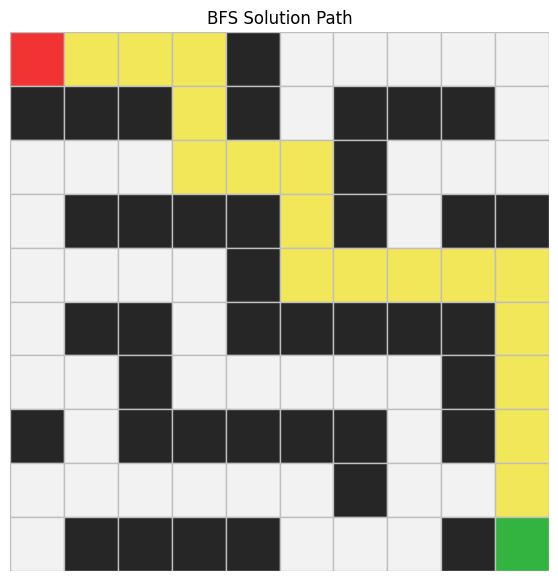

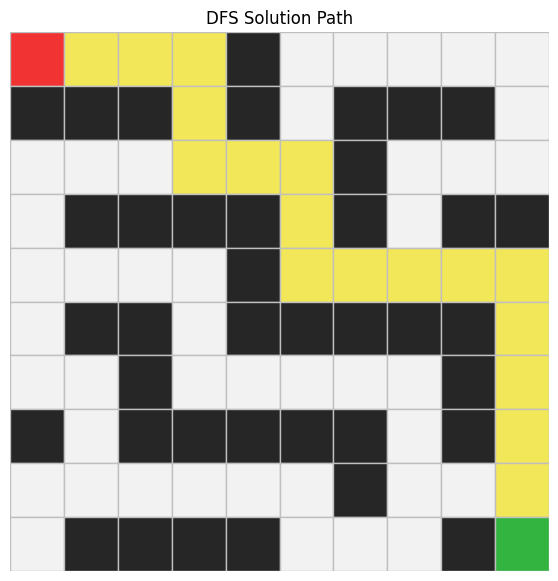

In [30]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

[[0. 1. 1. 0. 1. 0.]
 [0. 1. 1. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]]


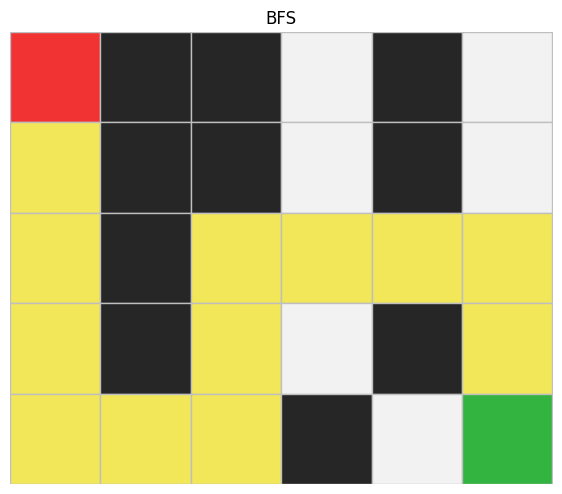

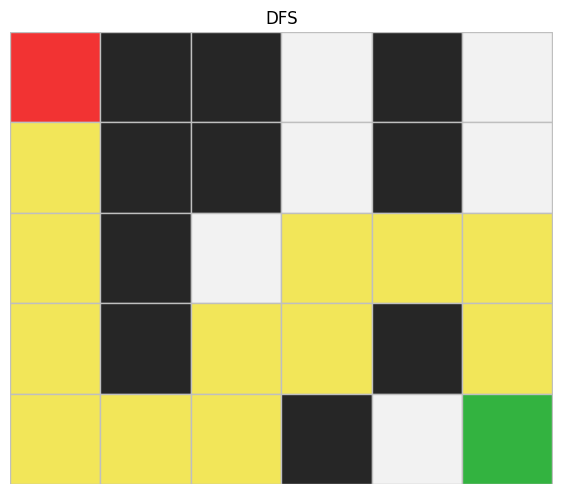

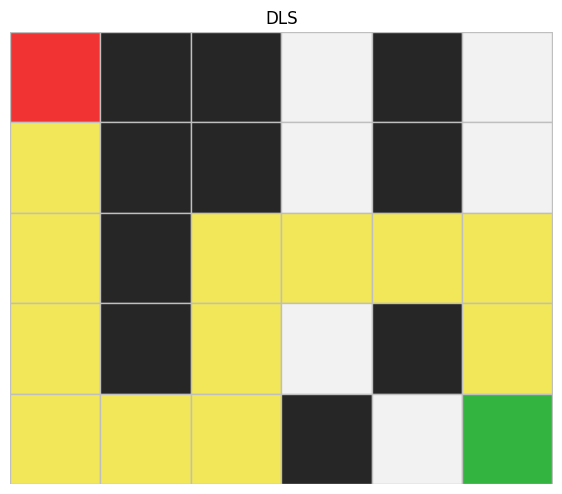

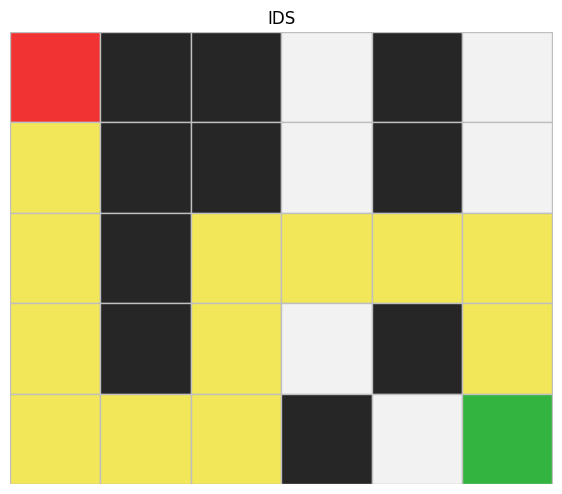

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,13,13,17,2,18
1,DFS,success,NaN,13,13,13,4,16
2,DLS,success,20.0,13,13,18,19,0
3,IDS,success,13.0,13,13,17,19,0


In [34]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 =np.zeros((5,6))
custom_grid_1[0:5,1:5]=np.random.randint(0,2,size=(5,4))
print(custom_grid_1)
custom_start_1 = (0,0)
custom_goal_1 = (4,5)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_problem_1=GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
bfs=BreadthFirstSearch()
dfs= DepthFirstSearch()
dls= DepthLimitedSearch()
ids=IterativeDeepeningSearch()
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=20),
     ids.search(custom_problem_1, max_depth=40),
 ]
bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]
dls_result = custom_results_1[2]
ids_result = custom_results_1[3]


plot_path(custom_grid_1,custom_start_1,custom_goal_1,path=bfs_result.path,title="BFS")
plot_path(custom_grid_1,custom_start_1,custom_goal_1,path=dfs_result.path,title="DFS")
plot_path(custom_grid_1,custom_start_1,custom_goal_1,path=dls_result.path,title="DLS")
plot_path(custom_grid_1,custom_start_1,custom_goal_1,path=ids_result.path,title="IDS")
show_results(custom_results_1)

[[0. 0. 0. 1. 1. 1. 1. 0.]
 [0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 1. 1. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 1. 0.]]


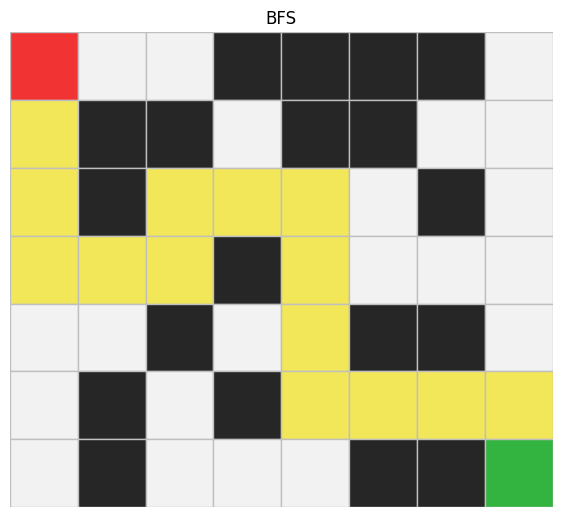

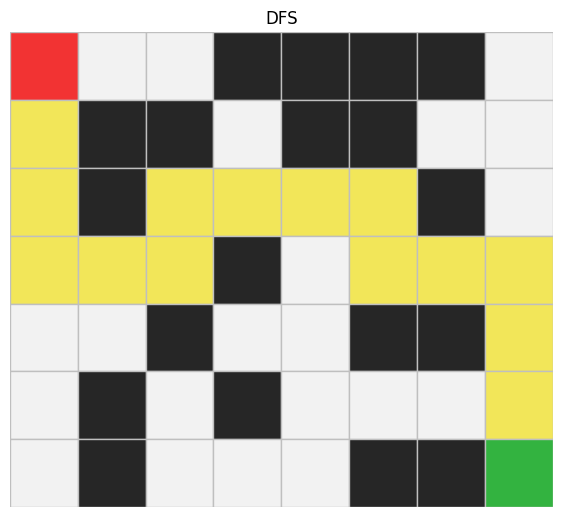

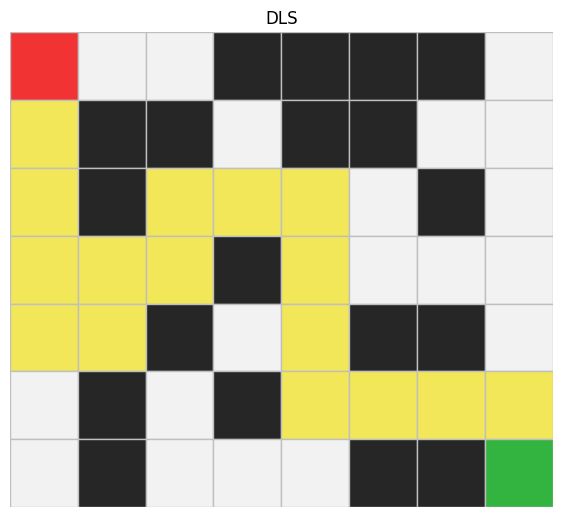

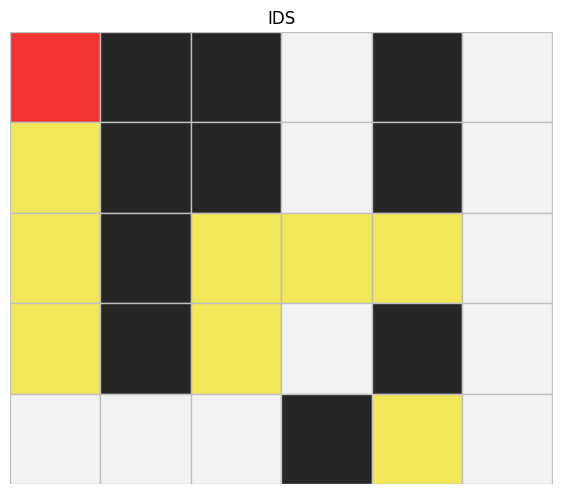

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,15,15,32,4,34
1,DFS,success,NaN,15,15,17,6,22
2,DLS,success,20.0,17,17,28,31,0
3,IDS,success,15.0,15,15,49,60,0


In [39]:
custom_grid_2=np.zeros((7,8))
custom_grid_2[0:7,1:7]=np.random.randint(0,2,size=(7,6))
print(custom_grid_2)
custom_start_2=(0,0)
custom_goal_2=(6,7)
custom_problem_2=GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
bfs=BreadthFirstSearch()
dfs= DepthFirstSearch()
dls= DepthLimitedSearch()
ids=IterativeDeepeningSearch()
custom_results_2 = [
     bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
     ids.search(custom_problem_2, max_depth=40),
 ]

bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]
dls_result = custom_results_2[2]
ids_result = custom_results_2[3]


plot_path(custom_grid_2,custom_start_2,custom_goal_2,path=bfs_result.path,title="BFS")
plot_path(custom_grid_2,custom_start_2,custom_goal_2,path=dfs_result.path,title="DFS")
plot_path(custom_grid_2,custom_start_2,custom_goal_2,path=dls_result.path,title="DLS")
plot_path(custom_grid_1,custom_start_2,custom_goal_2,path=ids_result.path,title="IDS")
show_results(custom_results_2)

In [1]:
# 15. Reflection Questions

#Answer the questions below in markdown cells.

## 15.1 Problem Formulation
'''
1. What is a state in this lab? The state in this case would be the position of the drone in the matrix, represented by a tuple (row,column)
2. What is an action? An action is the applicable movements the drone can carry out to move from one state to another.
3. What does the `result` function do? The result function shows the new state the drone has entered as a result of the action it took
4. Why is it useful to separate the problem definition from the search algorithm? The problem definition could contain more information than what the search algorithm actually needs. By separating it from the search algorithm, we can abstract what is necessary and save space.

## 15.2 BFS

1. Why does BFS use a FIFO queue? The BFS aims to expand all the nodes at a given level before moving on to the next level, as more nodes are expanded and are added to the queue, the FIFO queue ensures that the nodes that were added earlier are epanded before we move on to the nodes that were added later, this ensures alll nodes on the same level are expanded before moving on to the next level.
2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid? In an unweighted grid all path_costs are the same, and a BFS searches all the closest nodes first before moving on to the next level, if the action costs are the same and a MFS operates by checking nodes in the vicinity closet to it and works outward, then it means that the first solution it finds is the cheapest and the closest to it, since the other solutions it may find will be further away and therefore cost more
3. What role does the `reached` set play in BFS? It shows the nodes we have gotten to prevent us from going back to explore them unnecessarily again.

## 15.3 DFS

1. Why does DFS use a stack? A stack pops the node at the end of the list to expand next, because nodes on the same level will be towards the front of the list, the stack ensures we will be going deeper into a node by popping the nodes at the next level which will be at the end of stack
2. Is DFS guaranteed to find the shortest path? Explain. No it isn't. In a case where we have two nodes on the same level,  the node we choose to explore might be deeper than the one we chose to ignore, thus it doesn't guarantee the shortest route
3. Under what conditions can DFS use less memory than BFS? In a situation where the solution is found within a node that is relatively shallow, it will use less space than a BFS which would explore all the nodes on the given level before proceeding deeper
4. Under what conditions can DFS perform badly? In a situation where a node has very deep, A DFS will keep going deeper, instead of exploring an alternative solution

## 15.4 DLS

1. What happens when the depth limit is too small? If the limit is too small, the search algorithm may terminate prematurely, before we find a solution
2. What is the meaning of `"cutoff"`? This means that we explored as far as the limit and didn't find a solution, so we abandoned that path
3. How is DLS different from ordinary DFS? A DFS would keep on going deeper even if a node didn't have an end while a DLS would terminate after a certain point
4. Why do we use path-cycle checking in DLS? It prevents us from revisiting a node that is already on the search path

## 15.5 IDS

1. Why does IDS repeat DLS with increasing limits? If in the current iteration, the search algorithm was unable to yield a result because we didn;t explore deep enough, increasing the limit enables us to go to another level of expnasion in order to find a solution
2. Why can IDS be complete even though DLS with a small limit is not? After a small limit, if no solution is found, the DLS ends, but with IDS the limit will increase and keep iterating till a solution is found
3. Why does IDS use less memory than BFS? The IDS only stores nodes on the current path being explored, while a BFS stores all the nodes at a given level
4. What is the cost of repeatedly searching from the root? The same nodes are expanded repeatedly

## 15.6 Real-World Drone Context

1. In a real drone application, what might make one route safer or more practical than another? If one route is known to experience bettter weather than another, then it proves to be safer than another route, since weather can affect the drones traversal of the terrain
2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain. The BFS, if all moves have the same cost the BFS will ensure that the first solution i find will be the fastest solution since it would be closer to the intial node than any other alternatives
3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain. The DLS, this ensures that the search will be  cutoff after the limit to the expansion has been reached
4. What limitations does this grid model have compared with real drone navigation? This grid model does not account for things like weather which might make a short route seem longer and more dangerous in real practice
'''


SyntaxError: invalid syntax (3704920245.py, line 3)